# Real-Time Fraud Detection: Offline Model Training

This notebook trains and exports a reproducible fraud-detection model for the streaming application.

**Outputs:**
- `fraud_pipeline.joblib`
- `threshold.json`
- `feature_schema.json`
- `model_metadata.json`
- `metrics.json`
- `test_samples.csv`

The historical dataset is used for offline training. It will later be replayed locally to simulate a real-time transaction stream.

## 1. Environment and reproducibility

In [1]:
import os
import sys
import json
import glob
import platform
import warnings
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    precision_recall_curve, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("Platform:", platform.platform())

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas: 2.3.3
scikit-learn: 1.6.1
XGBoost: 3.2.0
Platform: Linux-6.12.90+-x86_64-with-glibc2.35


## 2. Locate and load the Kaggle dataset

Add the **Credit Card Fraud Detection** dataset to the notebook through **Add Input**. The cell searches Kaggle inputs automatically, so it does not depend on one fixed folder name.

In [2]:
candidates = glob.glob("/kaggle/input/**/creditcard.csv", recursive=True)
if not candidates:
    raise FileNotFoundError(
        "creditcard.csv was not found. In Kaggle, select Add Input and attach the Credit Card Fraud Detection dataset."
    )

DATA_PATH = candidates[0]
df = pd.read_csv(DATA_PATH)
print("Dataset:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Dataset: /kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Data-quality and leakage checks

In [3]:
EXPECTED_TARGET = "Class"
assert EXPECTED_TARGET in df.columns, f"Missing target column: {EXPECTED_TARGET}"
assert df[EXPECTED_TARGET].isin([0, 1]).all(), "Target must contain only 0 and 1"

quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False)
})

print("Duplicate rows:", df.duplicated().sum())
print("Fraud observations:", int(df[EXPECTED_TARGET].sum()))
print("Fraud rate: {:.6%}".format(df[EXPECTED_TARGET].mean()))
quality_report

Duplicate rows: 1081
Fraud observations: 492
Fraud rate: 0.172749%


,dtype,missing,unique
Time,float64,0,124592
V1,float64,0,275663
V2,float64,0,275663
V3,float64,0,275663
V4,float64,0,275663
V5,float64,0,275663
V6,float64,0,275663
V7,float64,0,275663
V8,float64,0,275663
V9,float64,0,275663


## 4. Compact exploratory analysis

Class
0    284315
1       492
Name: count, dtype: int64


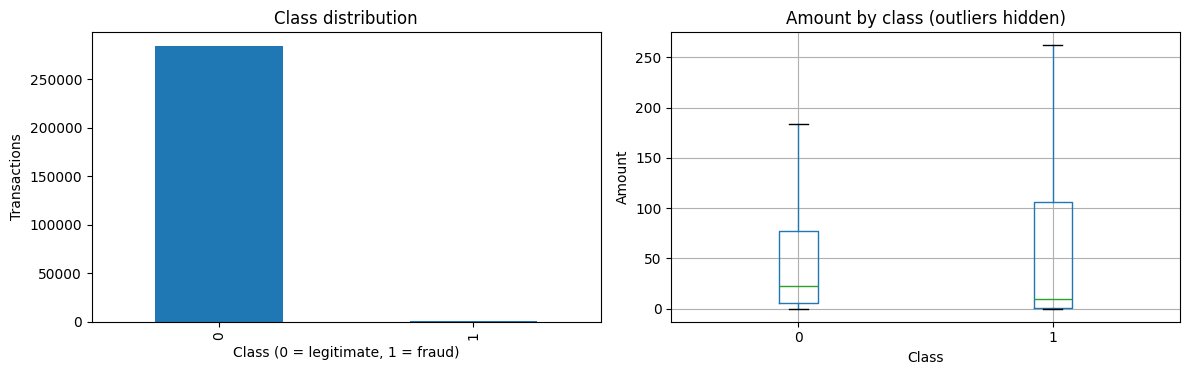

In [4]:
class_counts = df["Class"].value_counts().sort_index()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind="bar", ax=axes[0], title="Class distribution")
axes[0].set_xlabel("Class (0 = legitimate, 1 = fraud)")
axes[0].set_ylabel("Transactions")

df.boxplot(column="Amount", by="Class", ax=axes[1], showfliers=False)
axes[1].set_title("Amount by class (outliers hidden)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Amount")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 5. Train, validation, and test split

A stratified split is used because this public dataset does not provide a true transaction date. The `Time` field is elapsed seconds rather than a calendar timestamp. Validation and test data remain untouched by resampling.

In [5]:
X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

for name, features, target in [
    ("train", X_train, y_train),
    ("validation", X_valid, y_valid),
    ("test", X_test, y_test),
]:
    print(f"{name:10s}: rows={len(features):6d}, fraud={target.sum():3d}, rate={target.mean():.6%}")

train     : rows=199364, fraud=344, rate=0.172549%
validation: rows= 42721, fraud= 74, rate=0.173217%
test      : rows= 42722, fraud= 74, rate=0.173213%


## 6. Preprocessing

`Amount` and `Time` are standardized. PCA-derived `V1` to `V28` features are passed through after median imputation. Column names and order are captured in the exported schema.

In [6]:
scaled_features = [c for c in ["Time", "Amount"] if c in X.columns]
other_features = [c for c in X.columns if c not in scaled_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), scaled_features),
        ("other", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), other_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Scaled:", scaled_features)
print("Other feature count:", len(other_features))

Scaled: ['Time', 'Amount']
Other feature count: 28


## 7. Evaluation helpers and threshold selection

The threshold is selected on the validation set, never on the test set. By default, the notebook chooses the threshold with the highest F1 score. You can later replace this with a business-cost rule.

In [8]:
def select_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best_idx = int(np.nanargmax(f1))
    return {
        "threshold": float(thresholds[best_idx]),
        "validation_precision": float(precision[best_idx]),
        "validation_recall": float(recall[best_idx]),
        "validation_f1": float(f1[best_idx]),
        "selection_rule": "maximum_validation_f1"
    }


def evaluate_model(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "false_positives_per_1000": float(fp / len(y_true) * 1000),
        "threshold": float(threshold)
    }

## 8. Baseline: class-weighted logistic regression

In [9]:
logistic_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=SEED
    ))
])

logistic_pipeline.fit(X_train, y_train)
logistic_valid_prob = logistic_pipeline.predict_proba(X_valid)[:, 1]
logistic_threshold = select_threshold(y_valid, logistic_valid_prob)
logistic_metrics = evaluate_model(y_valid, logistic_valid_prob, logistic_threshold["threshold"])
print(json.dumps(logistic_metrics, indent=2))

{
  "pr_auc": 0.6275251631550334,
  "roc_auc": 0.9684146535449089,
  "precision": 0.8,
  "recall": 0.7567567567567568,
  "f1": 0.7777777777777778,
  "true_negatives": 42633,
  "false_positives": 14,
  "false_negatives": 18,
  "true_positives": 56,
  "false_positives_per_1000": 0.3277076847452073,
  "threshold": 0.9999996620801322
}


## 9. XGBoost with class weighting

This is the primary deployment candidate. The notebook detects whether CUDA is available and otherwise uses CPU safely.

In [10]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

try:
    import subprocess
    gpu_available = subprocess.run(
        ["nvidia-smi"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    ).returncode == 0
except Exception:
    gpu_available = False

xgb_params = {
    "n_estimators": 600,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 2,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
}
if gpu_available:
    xgb_params["device"] = "cuda"

print("GPU available:", gpu_available)
print("scale_pos_weight:", scale_pos_weight)

xgb_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(**xgb_params))
])

xgb_pipeline.fit(X_train, y_train)
xgb_valid_prob = xgb_pipeline.predict_proba(X_valid)[:, 1]
xgb_threshold = select_threshold(y_valid, xgb_valid_prob)
xgb_metrics = evaluate_model(y_valid, xgb_valid_prob, xgb_threshold["threshold"])
print(json.dumps(xgb_metrics, indent=2))

GPU available: True
scale_pos_weight: 578.546511627907
{
  "pr_auc": 0.8364164836283232,
  "roc_auc": 0.9791664950292756,
  "precision": 0.9655172413793104,
  "recall": 0.7567567567567568,
  "f1": 0.8484848484848485,
  "true_negatives": 42645,
  "false_positives": 2,
  "false_negatives": 18,
  "true_positives": 56,
  "false_positives_per_1000": 0.04681538353502961,
  "threshold": 0.9152204990386963
}


## 10. Compare candidates and select a model

In [11]:
comparison = pd.DataFrame([
    {"model": "logistic_regression", **logistic_metrics},
    {"model": "xgboost", **xgb_metrics},
]).sort_values("pr_auc", ascending=False)
comparison

,model,pr_auc,roc_auc,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,false_positives_per_1000,threshold
1,xgboost,0.836416,0.979166,0.965517,0.756757,0.848485,42645,2,18,56,0.046815,0.91522
0,logistic_regression,0.627525,0.968415,0.800000,0.756757,0.777778,42633,14,18,56,0.327708,1.00000


## 11. Final test evaluation

The XGBoost pipeline is selected as the streaming deployment candidate. Its decision threshold was determined on validation data and is now evaluated once on untouched test data.

In [14]:
final_pipeline = xgb_pipeline
threshold_info = xgb_threshold
selected_threshold = threshold_info["threshold"]

test_probabilities = final_pipeline.predict_proba(X_test)[:, 1]
test_metrics = evaluate_model(y_test, test_probabilities, selected_threshold)
test_predictions = (test_probabilities >= selected_threshold).astype(int)

print(json.dumps(test_metrics, indent=2))
print("Classification report:")
print(classification_report(y_test, test_predictions, digits=4, zero_division=0))

{
  "pr_auc": 0.8417739725281347,
  "roc_auc": 0.9699196945961155,
  "precision": 0.9365079365079365,
  "recall": 0.7972972972972973,
  "f1": 0.8613138686131386,
  "true_negatives": 42644,
  "false_positives": 4,
  "false_negatives": 15,
  "true_positives": 59,
  "false_positives_per_1000": 0.09362857544122466,
  "threshold": 0.9152204990386963
}
Classification report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     42648
           1     0.9365    0.7973    0.8613        74

    accuracy                         0.9996     42722
   macro avg     0.9681    0.8986    0.9305     42722
weighted avg     0.9995    0.9996    0.9995     42722



## 12. Export deployment artifacts

In [15]:
OUTPUT_DIR = "/kaggle/working/fraud-model-artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_version = "1.0.0"
feature_schema = {
    "schema_version": "1.0",
    "target": "Class",
    "features": [
        {"name": col, "dtype": str(X[col].dtype), "position": idx}
        for idx, col in enumerate(X.columns)
    ]
}

metadata = {
    "model_name": "xgboost_fraud_detector",
    "model_version": model_version,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_rows": int(len(df)),
    "training_rows": int(len(X_train)),
    "validation_rows": int(len(X_valid)),
    "test_rows": int(len(X_test)),
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__,
    "xgboost_version": xgb.__version__,
    "random_seed": SEED,
    "uses_gpu": bool(gpu_available),
    "model_class": type(final_pipeline.named_steps["classifier"]).__name__,
}

threshold_export = {
    "decision_threshold": float(selected_threshold),
    **threshold_info
}

metrics_export = {
    "validation": xgb_metrics,
    "test": test_metrics,
    "baseline_validation": logistic_metrics
}

joblib.dump(final_pipeline, os.path.join(OUTPUT_DIR, "fraud_pipeline.joblib"))
for filename, payload in [
    ("threshold.json", threshold_export),
    ("feature_schema.json", feature_schema),
    ("model_metadata.json", metadata),
    ("metrics.json", metrics_export),
]:
    with open(os.path.join(OUTPUT_DIR, filename), "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)

sample_count = min(200, len(X_test))
test_samples = X_test.iloc[:sample_count].copy()
test_samples["actual_label"] = y_test.iloc[:sample_count].to_numpy()
test_samples["expected_probability"] = test_probabilities[:sample_count]
test_samples["expected_prediction"] = test_predictions[:sample_count]
test_samples.to_csv(os.path.join(OUTPUT_DIR, "test_samples.csv"), index=False)

print("Exported files:")
for path in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*"))):
    print(" -", path)

Exported files:
 - /kaggle/working/fraud-model-artifacts/feature_schema.json
 - /kaggle/working/fraud-model-artifacts/fraud_pipeline.joblib
 - /kaggle/working/fraud-model-artifacts/metrics.json
 - /kaggle/working/fraud-model-artifacts/model_metadata.json
 - /kaggle/working/fraud-model-artifacts/test_samples.csv
 - /kaggle/working/fraud-model-artifacts/threshold.json


## 13. Reload and verify the exported model

In [16]:
reloaded_pipeline = joblib.load(os.path.join(OUTPUT_DIR, "fraud_pipeline.joblib"))
reloaded_probabilities = reloaded_pipeline.predict_proba(X_test.iloc[:200])[:, 1]

np.testing.assert_allclose(
    reloaded_probabilities,
    test_probabilities[:200],
    rtol=1e-7,
    atol=1e-9
)
assert np.all((reloaded_probabilities >= 0) & (reloaded_probabilities <= 1))
print("Verification passed: exported model reproduces the original probabilities.")

Verification passed: exported model reproduces the original probabilities.


## 14. Create one downloadable ZIP file

In [17]:
import shutil
zip_path = shutil.make_archive(
    "/kaggle/working/fraud-model-artifacts",
    "zip",
    OUTPUT_DIR
)
print("Download this file from the Kaggle Output panel:", zip_path)

Download this file from the Kaggle Output panel: /kaggle/working/fraud-model-artifacts.zip
